Datu kopa: 12330 rindas, 28 kolonnas
Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']
Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                     -0.00                    0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00         0.00       0.00       -0.00  
std                       1.00         1.00       1.

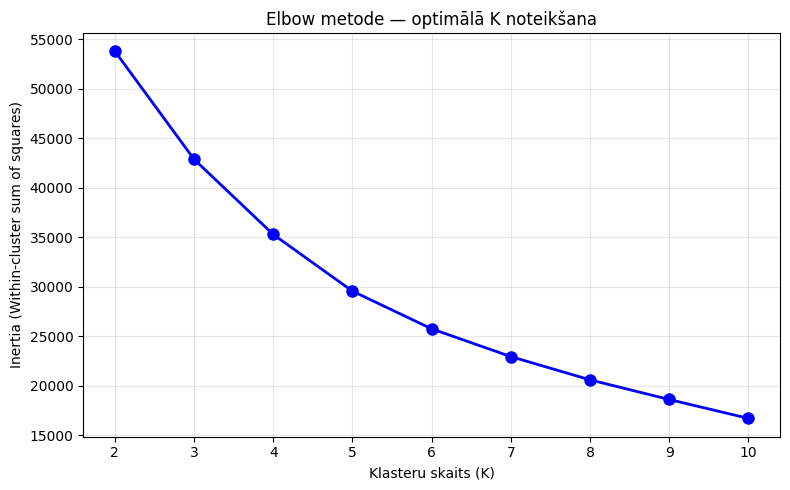


Klasteru sadalījums:
Cluster
0    9872
1     656
2     931
3     871
Name: count, dtype: int64


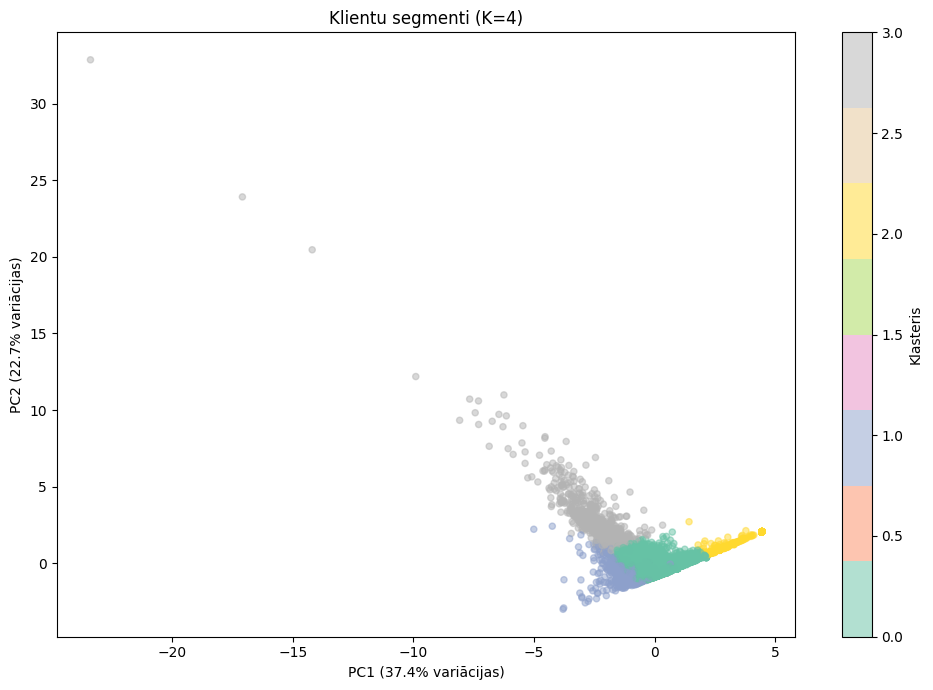


 Klasteru profili (vidējās vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          -0.14                   -0.15   
1                           0.06                   -0.09   
2                          -0.45                   -0.24   
3                           2.01                    2.03   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                          -0.11        -0.25      -0.20       -0.19  
1                           0.02        -0.40      -0.59        3.33  
2                          -0.60         3.24       2.96       -0.32  
3                           1.92        -0.32      -0.46        0.03  


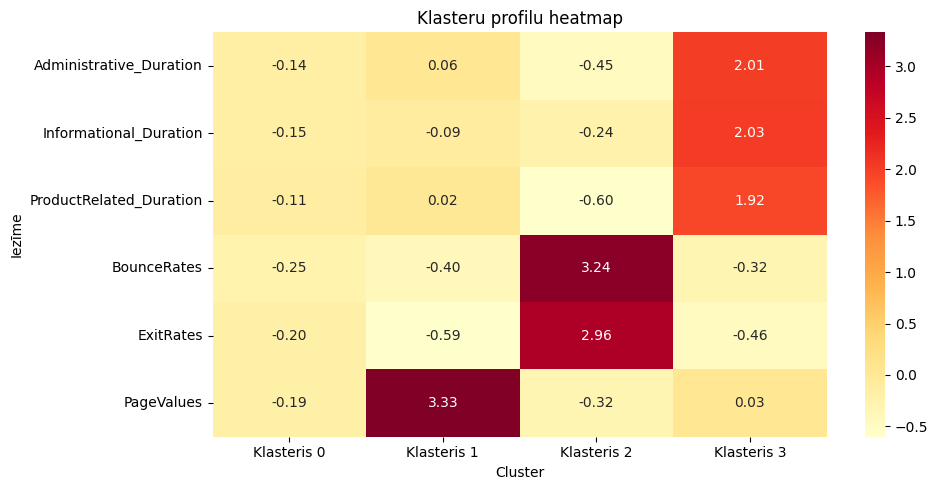


 Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.115
1    0.791
2    0.005
3    0.281
Name: Revenue, dtype: float64


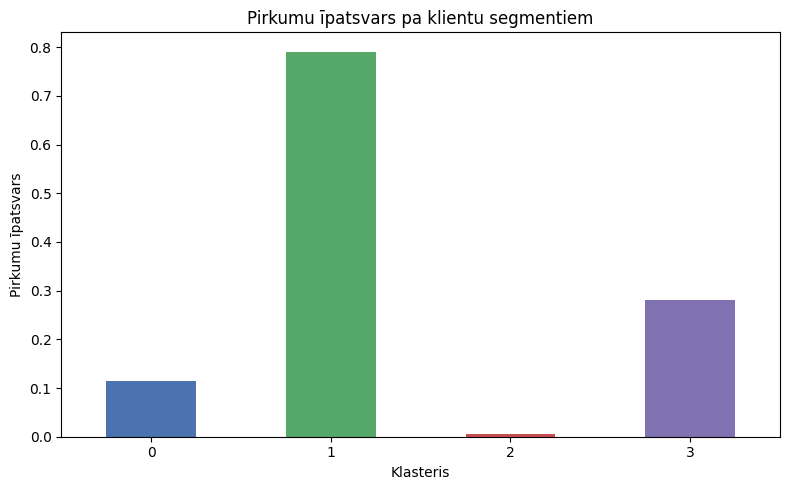


 Datu kopa: 12330 rindas, 27 features

 Viena split F1 score: 0.635

 5-fold CV F1 scores: [0.668 0.661 0.652 0.551 0.612]
Vidējais F1: 0.629
Standarta novirze: 0.043


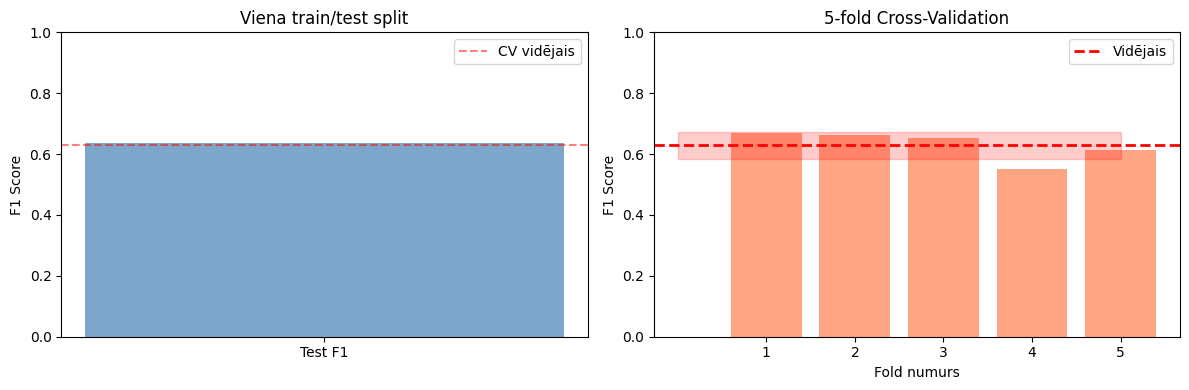


F1 ar data leakage: 0.635

F1 ar Pipeline: 0.629 ± 0.045
                     Metode  F1 Score             Ticamība
 Data leakage (viena split)  0.635258 BĪSTAMS! Neobjektīvs
Pipeline + Cross-validation  0.628553     DROŠS! Objektīvs
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1 (treniņā): 0.653
Test F1 (ar labākajiem parametriem): 0.629

Top 5 parametru kombinācijas:
   param_randomforestclassifier__n_estimators  \
8                                         200   
7                                         100   
5                                         200   
4                                         100   
6                                          50   

   param_randomforestclassifier__max_depth  mean_test_score  std_test_score  
8                                       20         0.653164        0.012239  
7                                       2

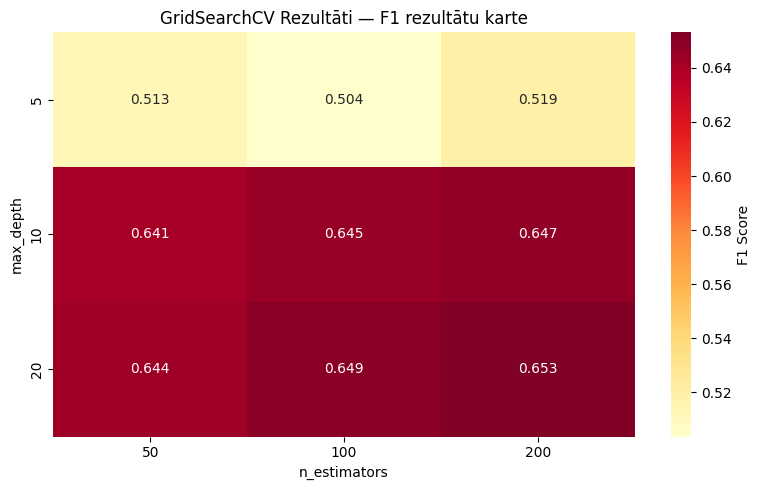


GridSearchCV:


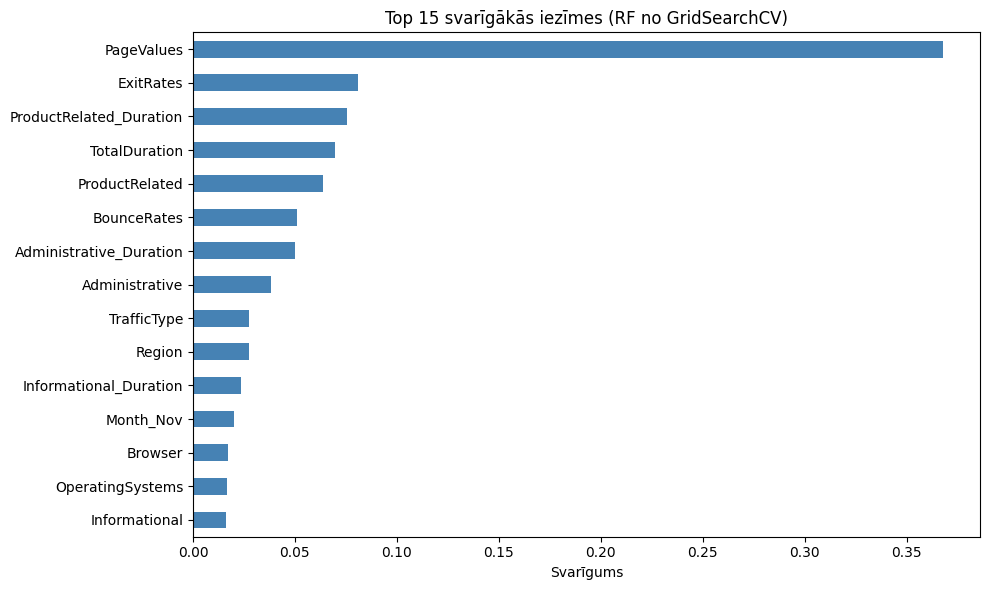


Top 10 svarīgākās iezīmes:
PageValues                 0.367569
ExitRates                  0.081168
ProductRelated_Duration    0.075586
TotalDuration              0.069522
ProductRelated             0.063952
BounceRates                0.050973
Administrative_Duration    0.049905
Administrative             0.038452
TrafficType                0.027520
Region                     0.027481
dtype: float64

Modeļu salīdzinājums: RandomForest vs. XGBoost

RandomForest CV F1: 0.635 ± 0.043
XGBoost CV F1:      0.614 ± 0.056

Tabula
     Modelis  CV vidējais F1  Std dev   Diapazons
RandomForest        0.634523 0.042623 0.572-0.689
     XGBoost        0.613835 0.056357 0.538-0.697


/tmp/ipykernel_3399/1545274886.py:382: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(models_scores, labels=['RandomForest', 'XGBoost'])


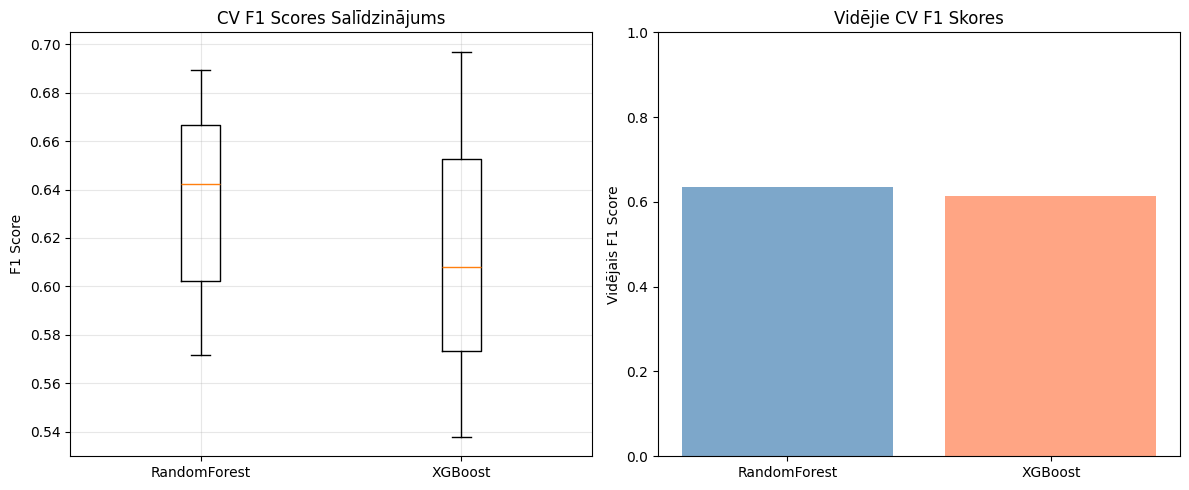

In [ ]:
# 1.1. Ielādē un sagatavo datus
# Izveido jaunu notebook week3/week3_homework.ipynb:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

# 1.2. Izvēlies features klasterizācijai
# Klasterizācijā mēs neizmantojam target mainīgo — mēs meklējam dabiskās grupas datos. Izvēlies 3–5 skaitliskas iezīmes, kas raksturo klientu uzvedību:
# Izvēlamies iezīmes, kas raksturo klientu sesiju
cluster_features = ['Administrative_Duration', 'Informational_Duration',
                     'ProductRelated_Duration', 'BounceRates', 'ExitRates',
                     'PageValues']


X_cluster = df[cluster_features].copy()
# gribēju paspēlēties ar šiem nākošiem 3
# X_cluster_start = pd.DataFrame(X_scaled, columns=cluster_features)
# print('/n ===X_claster_start===')
# print(X_cluster_start.describe().round(2))

print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)

# 1.3. Normalizē datus
# K-Means ir jūtīgs pret datu mērogu, tāpēc normalizācija ir obligāta:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Pārvēršam atpakaļ uz DataFrame ērtākai darbībai
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
print("Pēc normalizācijas:")
print(X_scaled_df.describe().round(2))

# 2. uzdevums. Atrodi optimālo klasteru skaitu (Elbow Method)
# 2.1. Elbow metode
# Izmanto Elbow metodi, lai noteiktu, cik klasteru ir optimāli:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

print("\n ===Elbow metode — optimālā K noteikšana===")
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. uzdevums. Veic klasterizāciju un vizualizē
# 3.1. Uztrenē galīgo K-Means modeli
# Izmanto izvēlēto K vērtību (piemēram, 4)
K = 4  # <-- nomainiet uz savu izvēlēto vērtību

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"\nKlasteru sadalījums:")
print(df['Cluster'].value_counts().sort_index())
# 3.2. Vizualizē klasterus ar PCA
from sklearn.decomposition import PCA

# Samazinām dimensijas līdz 2 vizualizācijai
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()

# 3.3. Klasteru profili un heatmap
# Katra klastera vidējās vērtības (pirms normalizācijas — lai būtu interpretējami)
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()

cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)
print("\n Klasteru profili (vidējās vērtības):")
print(cluster_profiles)

# Vizuāli — heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()

# 4. uzdevums. Interpretē klasterus biznesa kontekstā
# 4.1. Klasteru raksturojums ar pirkumiem
# Cik procentu katra klastera klientu veica pirkumu?
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)
print("\n Pirkumu īpatsvars pa klasteriem:")
print(purchase_by_cluster)

plt.figure(figsize=(8, 5))
purchase_by_cluster.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. uzdevums. Viena split vs. Cross-validation
# 5.1. Ielādē datus un modeļi
# Turpinājums tajā pašā notebook week3/week3_homework.ipynb:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Ielādē datus (tu tos jau ielādēji, tāpēc varētu būt kļūda)
y = df['Revenue']
X = df.drop(['Revenue', 'Cluster'], axis=1)  # Izņem mūsu klasteru kolonu

print(f"\n Datu kopa: {X.shape[0]} rindas, {X.shape[1]} features")

# 5.2. Viena train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))

print(f"\n Viena split F1 score: {single_f1:.3f}")

# 5.3. Cross-validation (5-fold)
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

cv_scores = cross_val_score(
    rf_cv, X, y,
    cv=5,
    scoring='f1'
)

print(f"\n 5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f}")
print(f"Standarta novirze: {cv_scores.std():.3f}")

#  5.4. Vizualizācija
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Viena split
axes[0].bar(['Test F1'], [single_f1], color='steelblue', alpha=0.7)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Viena train/test split')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=cv_scores.mean(), color='red', linestyle='--', alpha=0.5, label='CV vidējais')
axes[0].legend()

# Cross-validation
axes[1].bar(range(1, 6), cv_scores, color='coral', alpha=0.7)
axes[1].axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label='Vidējais')
axes[1].fill_between(
    range(0, 6),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.2, color='red'
)
axes[1].set_xlabel('Fold numurs')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('5-fold Cross-Validation')
axes[1].set_ylim([0, 1])
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.tight_layout()
plt.show()

# 6. uzdevums. Pipeline un data leakage
# 6.1. Bīstama versija: data leakage
# Vienkārši parādi, ko NAV jādara:
from sklearn.preprocessing import StandardScaler

# ✗ NEPAREIZI - data leakage!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # ← Fit uz VISIEM datiem!

X_train_leaked, X_test_leaked, y_train_l, y_test_l = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

rf_leaked = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_leaked.fit(X_train_leaked, y_train_l)
f1_leaked = f1_score(y_test_l, rf_leaked.predict(X_test_leaked))

print(f"\nF1 ar data leakage: {f1_leaked:.3f}")

# 6.2. Pareizā versija: Pipeline
# Tā kā būtu jāveic:
from sklearn.pipeline import make_pipeline

# ✓ PAREIZI - Pipeline
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

# Trenēšana ar cross-validation
cv_scores_pipe = cross_val_score(
    pipe, X, y,
    cv=5,
    scoring='f1'
)

print(f"\nF1 ar Pipeline: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")
# 6.3. Salīdzinājums
comparison = pd.DataFrame({
    'Metode': ['Data leakage (viena split)', 'Pipeline + Cross-validation'],
    'F1 Score': [f1_leaked, cv_scores_pipe.mean()],
    'Ticamība': ['BĪSTAMS! Neobjektīvs', 'DROŠS! Objektīvs']
})

print(comparison.to_string(index=False))

# 7. uzdevums. GridSearchCV
# 7.1. Parametru tīkls un meklēšana
from sklearn.model_selection import GridSearchCV

# Pipeline, kam meklēsim parametrus
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru tīkls — 2 parametri, 3×3 kombinācijas = 9 mēģinājumi
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

# GridSearchCV: cross-validation + automātiska meklēšana
grid = GridSearchCV(
    pipe, param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,  # Izmanto visas CPU kodolus
    verbose=1
)

# Trenēšana (tikai uz training datiem!)
X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

grid.fit(X_train_gs, y_train_gs)

print(f"\nLabākie parametri: {grid.best_params_}")
print(f"Labākais CV F1 (treniņā): {grid.best_score_:.3f}")
print(f"Test F1 (ar labākajiem parametriem): {f1_score(y_test_gs, grid.predict(X_test_gs)):.3f}")

# 7.2. Detalizēta rezultātu analīze
# Kādi bija VISIEM parametriem?
results_df = pd.DataFrame(grid.cv_results_)
results_table = results_df[[
    'param_randomforestclassifier__n_estimators',
    'param_randomforestclassifier__max_depth',
    'mean_test_score',
    'std_test_score'
]].sort_values('mean_test_score', ascending=False)

print("\nTop 5 parametru kombinācijas:")
print(results_table.head())

# 7.3. Vizualizācija: heatmap
# Pivot tabula — n_estimators kolonnas, max_depth rindas
print("\nPivot tabula — n_estimators kolonnas, max_depth rindas:")
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    cbar_kws={'label': 'F1 Score'}
)
plt.title('GridSearchCV Rezultāti — F1 rezultātu karte')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()

# 8. uzdevums. Feature importance
# 8.1. Feature importance no labākā modeļa
# Izmanto GridSearchCV labāko modeli:
# Iegūt labāko trenēto modeli
print("\nGridSearchCV:")
best_model = grid.best_estimator_

# RandomForestClassifier nodrošina feature_importances_
rf_inside = best_model.named_steps['randomforestclassifier']
importances = rf_inside.feature_importances_

# Sakārtot un vizualizēt
feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.tail(15).plot(kind='barh', color='steelblue')
plt.xlabel('Svarīgums')
plt.title('Top 15 svarīgākās iezīmes (RF no GridSearchCV)')
plt.tight_layout()
plt.show()

# Arī teksts
print("\nTop 10 svarīgākās iezīmes:")
print(feature_importance.sort_values(ascending=False).head(10))

# 9. uzdevums. Vienkāršs modeļu salīdzinājums: RandomForest vs. XGBoost
# 9.1. Abi modeļi ar cross-validation
print("\nModeļu salīdzinājums: RandomForest vs. XGBoost")
from xgboost import XGBClassifier

# RandomForest (ar labākajiem parametriem no GridSearchCV)
rf_final = RandomForestClassifier(
    n_estimators=grid.best_params_['randomforestclassifier__n_estimators'],
    max_depth=grid.best_params_['randomforestclassifier__max_depth'],
    random_state=42
)

pipe_rf = make_pipeline(StandardScaler(), rf_final)
cv_rf = cross_val_score(pipe_rf, X, y, cv=5, scoring='f1')

# XGBoost (standarta parametri, vienkāršības dēļ)
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42,
    eval_metric='logloss'
)

pipe_xgb = make_pipeline(StandardScaler(), xgb)
cv_xgb = cross_val_score(pipe_xgb, X, y, cv=5, scoring='f1')

# Salīdzinājums
print(f"\nRandomForest CV F1: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
print(f"XGBoost CV F1:      {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")

# 9.2. Detalizēta tabula
print("\nTabula")
comparison_table = pd.DataFrame({
    'Modelis': ['RandomForest', 'XGBoost'],
    'CV vidējais F1': [cv_rf.mean(), cv_xgb.mean()],
    'Std dev': [cv_rf.std(), cv_xgb.std()],
    'Diapazons': [f"{cv_rf.min():.3f}-{cv_rf.max():.3f}",
                  f"{cv_xgb.min():.3f}-{cv_xgb.max():.3f}"]
})

print(comparison_table.to_string(index=False))
# 9.3. Vizualizācija
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
models_scores = [cv_rf, cv_xgb]
axes[0].boxplot(models_scores, labels=['RandomForest', 'XGBoost'])
axes[0].set_ylabel('F1 Score')
axes[0].set_title('CV F1 Scores Salīdzinājums')
axes[0].grid(True, alpha=0.3)

# Bar plot ar vidējiem
axes[1].bar(['RandomForest', 'XGBoost'], [cv_rf.mean(), cv_xgb.mean()], alpha=0.7, color=['steelblue', 'coral'])
axes[1].set_ylabel('Vidējais F1 Score')
axes[1].set_title('Vidējie CV F1 Skores')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()



Markdown šūna: Paskaidro, kāpēc normalizācija ir svarīga klasterizācijai. Kas notiktu, ja mēs to nedarītu?
Normalizācija ir svarīga, jo ja ir milzīga ciparu dažādība (mērogs) modelis nesaprot kā tos salīdzināt un rezultāts būs bēdīgs, resp. lielākiem cipariem dos augstāku prioritāti, kas ne vienmēr ir pareizi. Tā kā mēs normalizāciju izdarījām iepriekš, tad šoreiz nekas nemainījās
2.2. Izvēlies K vērtību (Markdown šūna)
Apskatot grafiku, uzraksti Markdown šūnu, kurā:
- Paskaidro ko nozīmē K_range un kāpēc ir izvēlētas šādas vērtības (2-11)
K_range ir nosacīto grupu skaits (klāsteri) kurās modelis iedala datus. To skaits parasti ir līdz 10 (jo virs 10 nenozīmīgi mainās pievienotā vērtība)
- Norādi, kuru K vērtību tu izvēlies. Es izvēlējos K = 4
- Paskaidro, kā tu identificēji „elkoni” grafikā. Manuprāt pie ~ K = 6 mainās līknes straujums.
- Atzīmē, ka nav vienas „pareizas” atbildes — tā ir interpretācija.
Tā ir mana interpretācija, tik pat labi varēju ņemt arī blakus ciparus 3 vai 5

4.2. Biznesa interpretācija (Markdown šūna)
Uzraksti Markdown šūnu (vismaz 5–7 teikumi), kurā:
- Katram klasterim dod nosaukumu (piemēram, „Aktīvie pircēji”, „Izpētes apmeklētāji”, „Ātrie aizgājēji” u.c.).
0 klasteris - "Netīšām iemaldījās". Daudz apmeklētāju. Nezina ko meklē. Jāpiedāvā sākuma mazo bonusu 5%
1 klasteris - "Pastāvīgie klienti". Pērk daudz (80% no apmeklējuma). Bieži jāsūta reklāmas un jādod lielākā atlaide, klienta statuss utt.
2 klasteris - "Neapmierinātie, ātrie aizgājēji". Iespējams nepatika lapas dizains vai ielādes ātrums vai vispār šo produktu nevajag. Maz klikšķu, ātri aiziet. Analizējam iespējas ko uzlabot, bet nesaspringstam uz šiem.
3 klasteris - "Pētnieki, neizlēmīgie". Nopērk tomēr diezgan daudz (28%), jāpiedomā kā viņus uzrunāt ar papildus info vai ātriem papildus bonusiem.
- Apraksti, kas raksturo katru klientu grupu.
- Iesaki vismaz 1 konkrētu biznesa darbību katrai grupai (piemēram, „Šai grupai vajadzētu nosūtīt atlaižu piedāvājumu”).

5.5. Analīze (Markdown šūna)
Uzraksti Markdown šūnu (3–5 teikumi), kurā atbildi:
•	Kā atšķiras vienas split F1 un CV vidējais F1? Šajā gadījumā atšķliras ļoti maz. Viena split gadījumā ir bijis raksturīgs eksperiments.
Modelis ir veicis vairākus neatkarīgus eksperimentus.
•	Kurš rezultāts ir uzticamāks un kāpēc? CV vidējais ir uzticamāks, jo ņem vidējo no vairākiem kesperimentiem. 4 fold bija ievērojami zemāks rādītājs un ja tas būtu trāpījies viena split gadījumā, būtu citādi rezultāti
•	Ko parāda standarta novirze (std)?
Standarta novirze parāda, cik stabils ir modelis dažādos datos — mūsu gadījumā std ir maza, kas liecina par stabilu modeli.
•	Vai ir iespējams, ka “pārmēģinot” iegūtu pavisam citu vienas split F1? Jā, jo 4 fold bija citāds.

6.4. Skaidrojums (Markdown šūna)
Uzraksti Markdown šūnu (4–6 teikumi), kurā paskaidro:
•	Kas ir data leakage?
Data leakage ir variants, kad modelim tiek iedoti dati ar rezultātu vai tādus ko nedrīkst dot, resp. viņš nevis pats izveido modeli, bet uztaisa lai atbilstu jau paredzamam/zināmam rezultātam.
•	Kāpēc tas notiek, ja skalers tiek fit PIRMS split? Ja StandartScaler tiek palaists uz visiem datiem, tad modelis redz visus datus uzreiz un veido atbilstošu (pārāk optimistisku) rezultātu.
•	Kā Pipeline to novērš? Pipeline ir veidots tā, ka automātiski katram fold dod modelim tikai TRAIN daļu, bet testē uz pārējo.
•	Kāpēc tas ir kritisks gala projektā? Rezsultāti būs pārāk optimistiski, kas reālajā dzīvē var novest pie slikta lēmuma pieņemšanas.

7.4. Interpretācija (Markdown šūna)
Uzraksti Markdown šūnu (3–5 teikumi), kurā atbildi:
•	Kādi bija labākie parametri?
Labākie parametri bija n_estimators=200 un max_depth=20 ar CV F1 = 0.653. Starpība starp labāko (0.653) un sliktāko kombināciju (0.504, max_depth=5, n_estimators=100) bija 0.149 — tas liecina, ka parametru izvēle, ievērojami ietekmē rezultātu.

•	Cik liela bija atšķirība starp labāko un sliktāko kombināciju?
•	Vai heatmapā vari redzēt “karstas zonas” (augstāki F1 skores)?
Heatmapā skaidri redzamas "karstas zonas" — visas max_depth=10 un max_depth=20 kombinācijas ir tumši sarkanas (0.641–0.653), kamēr max_depth=5 rinda ir dzeltena (0.504–0.519). Tas parāda, ka max_depth ir daudz svarīgāks parametrs nekā n_estimators mūsu situācijā.

•	Vai GridSearchCV atrada labākus parametrus nekā tavi manuāli izvēlētie?
Salīdzinot ar manuāli izvēlētajiem parametriem (n_estimators=100, max_depth=10, F1=0.645), GridSearchCV atrada nedaudz labāku kombināciju (n_estimators=200, max_depth=20, F1=0.653) — uzlabojums ir neliels (0.008), taču automātiskā meklēšana apstiprināja, ka vairāk estimators dod labāku rezultātu.

8.2. Interpretācija (Markdown šūna)
Uzraksti Markdown šūnu, kurā:
•	Nosauc 3 svarīgākās iezīmes pēc nosaukuma
PageValue
ExitRate
ProductRelated_Duration
•	Paskaidro, kāpēc uzskati, ka šīs iezīmes ir svarīgas klienta pirkuma prognozēšanai
PageValue nodala vērtīgās produktu lapas un to apmeklēšana kopā ar ilgu uzturēšanos tajās un zemu ExitRate norāda par cilvēku interesi par šiem produktiem, iespējamām pārdomām vai šo produktu vajag, vai var atļauties utt, resp. reāla interese
•	Kā mārketinga departaments varētu izmantot šo informāciju?
Jāveicina šīs informācijas analīzi, apstrādi, izpratni un uz tā pamata var mēģināt papildus ietekmēt attiecīgos klientus ar bonusiem utt. Var arī konkrētās lapas mēģināt akcentēt vēl vairāk.

9.4. Secinājumi (Markdown šūna)
Uzraksti Markdown šūnu (3–5 teikumi):
•	Kurš modelis labāks: RandomForest vai XGBoost?
RandomForest, jo augstāks vidējais F1 un mazāka novirze, kas liecina, ka modelis ir stabilāks
•	Vai atšķirība ir statistiski nozīmīga?
Manuprāt ir statiski nenozīmīga
•	Kuru tu izvēlētos gala projektam un kāpēc?
Es palieku pie RandomForest,jo tas ir mazāk jūtīgs pret parametriem, precīzāks un stabilāks





